In [1]:
# Core PyTorch utilities
!pip install -q torchinfo torchview torchmetrics graphviz

# System dependency for graphviz (needed for SVG rendering)
!apt-get install -y graphviz



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [2]:
!pip install -q h5py torch torchvision torchmetrics tqdm seaborn matplotlib scikit-learn pillow



In [3]:
import zipfile
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from pathlib import Path
from PIL import Image

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassAUROC,
    MulticlassMatthewsCorrCoef
)
from torchinfo import summary
from torchview import draw_graph

sns.set_style("darkgrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [4]:
import zipfile
import os

ZIP_PATH = "/content/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui.zip"
EXTRACT_DIR = "/content/mendeley_dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction complete.")

Extraction complete.


In [5]:
import zipfile
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.lower().endswith(".zip"):
            inner_zip = os.path.join(root, file)
            print("Extracting:", inner_zip)

            with zipfile.ZipFile(inner_zip, "r") as z:
                z.extractall(EXTRACT_DIR)

print("Finished extracting nested ZIPs.")

Extracting: /content/mendeley_dataset/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui/Epic and CSCR hospital Dataset.zip
Finished extracting nested ZIPs.


In [6]:
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    print(root)

/content/mendeley_dataset
/content/mendeley_dataset/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui
/content/mendeley_dataset/Epic and CSCR hospital Dataset
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/glioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/pituitary
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/notumor
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/meningioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/glioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/pituitary
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/notumor
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/meningioma


In [7]:
from pathlib import Path
import pandas as pd
import random

random.seed(42)

# Root of extracted dataset
ROOT = Path("/content/mendeley_dataset/Epic and CSCR hospital Dataset")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

SAMPLES = {
    "glioma": 926,
    "meningioma": 937,
    "pituitary": 901,
    "notumor": 500,
}

def collect_images(folder, label):
    images = []

    if not folder.exists():
        print(f"Folder not found: {folder}")
        return images

    for img in folder.rglob("*"):
        if img.is_file() and img.suffix.lower() in IMAGE_EXTS:
            images.append({
                "image_path": str(img),
                "label": label
            })

    return images

# Collect all images
all_images = {}

for cls in SAMPLES.keys():

    imgs = []

    imgs.extend(
        collect_images(ROOT / "Train" / cls, cls)
    )

    imgs.extend(
        collect_images(ROOT / "Test" / cls, cls)
    )

    print(f"{cls:12s}: {len(imgs)} images found")

    random.shuffle(imgs)

    all_images[cls] = imgs[:SAMPLES[cls]]

# Combine
train_images = []
for cls in SAMPLES.keys():
    train_images.extend(all_images[cls])

# DataFrame
train_df = pd.DataFrame(train_images)

# Shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nCounts after sampling:")
print(train_df["label"].value_counts())

print("\nTotal images:", len(train_df))

train_df.head()

glioma      : 3773 images found
meningioma  : 2729 images found
pituitary   : 3130 images found
notumor     : 2432 images found

Counts after sampling:
label
meningioma    937
glioma        926
pituitary     901
notumor       500
Name: count, dtype: int64

Total images: 3264


,image_path,label
0,/content/mendeley_dataset/Epic and CSCR hospit...,meningioma
1,/content/mendeley_dataset/Epic and CSCR hospit...,glioma
2,/content/mendeley_dataset/Epic and CSCR hospit...,glioma
3,/content/mendeley_dataset/Epic and CSCR hospit...,glioma
4,/content/mendeley_dataset/Epic and CSCR hospit...,glioma


In [8]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

# Second split: temp -> 10% validation + 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

2611 326 327


In [9]:
label_to_index = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "notumor": 3
}

In [10]:
label_map = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "notumor": 3,
}

train_df["label"] = train_df["label"].map(label_map)
val_df["label"] = val_df["label"].map(label_map)

# Only if test_df exists
if "test_df" in globals():
    test_df["label"] = test_df["label"].map(label_map)

num_classes = len(label_map)

print(train_df.head())

                                          image_path  label
0  /content/mendeley_dataset/Epic and CSCR hospit...      0
1  /content/mendeley_dataset/Epic and CSCR hospit...      1
2  /content/mendeley_dataset/Epic and CSCR hospit...      0
3  /content/mendeley_dataset/Epic and CSCR hospit...      2
4  /content/mendeley_dataset/Epic and CSCR hospit...      0


In [11]:
class BrainTumorDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_loader = DataLoader(
    BrainTumorDataset(train_df, transform),
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    BrainTumorDataset(val_df, transform),
    batch_size=16
)

test_loader = DataLoader(
    BrainTumorDataset(test_df, transform),
    batch_size=16
)

print("DataLoaders ready.")



DataLoaders ready.


In [12]:
def apply_avg_2max_pool_to_image(img_tensor, pool_layer):
    """
    img_tensor: torch.Tensor of shape (3, H, W)
    returns pooled image resized back to original size
    """
    img = img_tensor.unsqueeze(0)  # (1, 3, H, W)

    pooled_channels = []
    for c in range(3):
        ch = img[:, c:c+1, :, :]          # (1,1,H,W)
        pooled = pool_layer(ch)           # downsampled
        pooled = torch.nn.functional.interpolate(
            pooled, size=img.shape[-2:], mode="bilinear", align_corners=False
        )
        pooled_channels.append(pooled)

    pooled_img = torch.cat(pooled_channels, dim=1)
    return pooled_img.squeeze(0)



In [13]:
import torch
import torch.nn as nn

class AvgTwiceMaxPooling2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.avg = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)
        self.max = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.avg(x) - 2 * self.max(x)



In [14]:
import random
import matplotlib.pyplot as plt

def visualize_original_vs_pooled(dataset, device, num_images=3):
    pool_layer = AvgTwiceMaxPooling2D().to(device)
    pool_layer.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(4 * num_images, 6))

    for i, idx in enumerate(indices):
        img, _ = dataset[idx]
        img = img.to(device)

        with torch.no_grad():
            pooled_img = apply_avg_2max_pool_to_image(img, pool_layer)

        orig = img.permute(1, 2, 0).cpu().numpy()
        pooled = pooled_img.permute(1, 2, 0).cpu().numpy()

        # Normalize for display
        orig = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)
        pooled = (pooled - pooled.min()) / (pooled.max() - pooled.min() + 1e-8)

        # Original
        plt.subplot(2, num_images, i + 1)
        plt.imshow(orig, cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Pooled
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(pooled, cmap="gray")
        plt.title("Avg − 2×Max pooled")
        plt.axis("off")

    plt.tight_layout()
    plt.show()



In [15]:
import torch
import torch.nn as nn

class MRINet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # 3 -> 21
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=3, padding=1),
            nn.BatchNorm2d(21),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 21 -> 34
        self.conv2 = nn.Sequential(
            nn.Conv2d(21, 34, kernel_size=3, padding=1),
            nn.BatchNorm2d(34),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 34 -> 55
        self.conv3 = nn.Sequential(
            nn.Conv2d(34, 55, kernel_size=3, padding=1),
            nn.BatchNorm2d(55),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 55 -> 89
        self.conv4 = nn.Sequential(
            nn.Conv2d(55, 89, kernel_size=3, padding=1),
            nn.BatchNorm2d(89),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 89 -> 144
        self.conv5 = nn.Sequential(
            nn.Conv2d(89, 144, kernel_size=3, padding=1),
            nn.BatchNorm2d(144),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 144 -> 233
        self.conv6 = nn.Sequential(
            nn.Conv2d(144, 233, kernel_size=3, padding=1),
            nn.BatchNorm2d(233),
            nn.ReLU(inplace=True)
        )

        # 233 -> 233
        self.conv7 = nn.Sequential(
            nn.Conv2d(233, 233, kernel_size=3, padding=1),
            nn.BatchNorm2d(233),
            nn.ReLU(inplace=True)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(233, num_classes)

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [16]:
num_classes = 4

In [17]:
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4

model = MRINet(num_classes).to(device)

summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    depth=5
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
MRINet                                   [1, 3, 224, 224]          [1, 4]                    --                        --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 21, 112, 112]         --                        --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 21, 224, 224]         588                       [3, 3]
│    └─BatchNorm2d: 2-2                  [1, 21, 224, 224]         [1, 21, 224, 224]         42                        --
│    └─ReLU: 2-3                         [1, 21, 224, 224]         [1, 21, 224, 224]         --                        --
│    └─MaxPool2d: 2-4                    [1, 21, 224, 224]         [1, 21, 112, 112]         --                        2
├─Sequential: 1-2                        [1, 21, 112, 112]         [1, 34, 56, 56]           --                        --
│    └─Conv

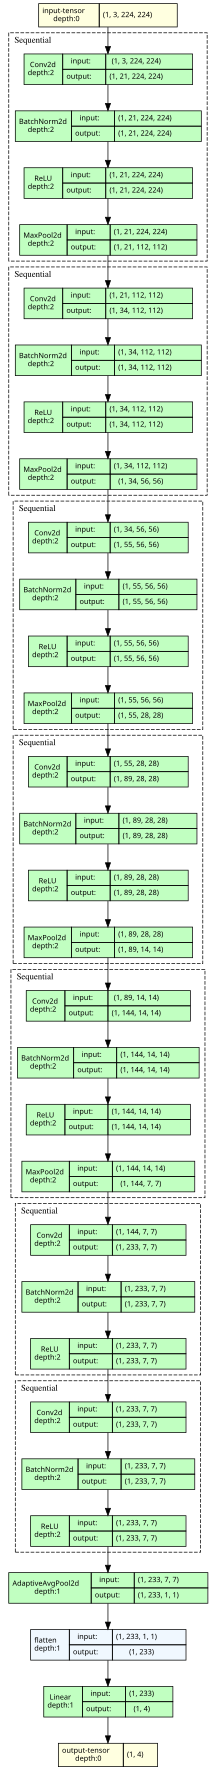

In [18]:

!pip install -q torchview graphviz
from torchview import draw_graph
from IPython.display import SVG, display

dummy = torch.randn(1, 3, 224, 224).to(device)

graph = draw_graph(
    model,
    input_data=dummy,
    expand_nested=True,
    graph_name="MRINet",
    save_graph=False
)

display(SVG(graph.visual_graph.pipe(format="svg")))



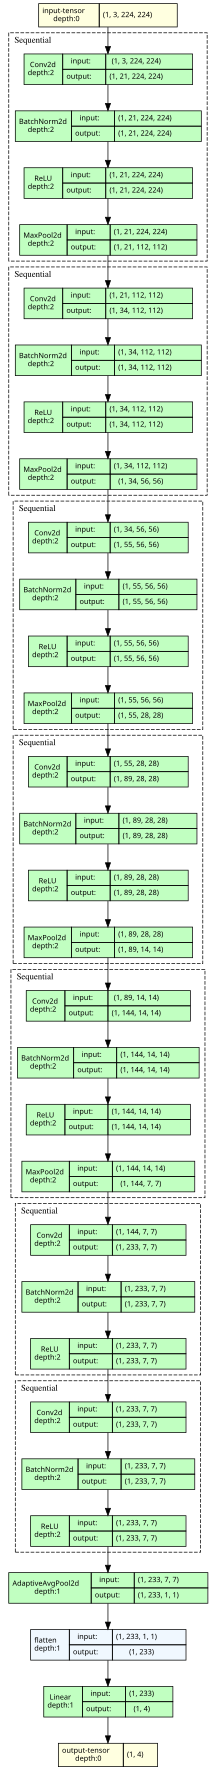

In [19]:
from torchview import draw_graph
from IPython.display import SVG, display

dummy_input = torch.randn(1, 3, 224, 224).to(device)

graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True,
    graph_name="MRINet",
    save_graph=True,              # IMPORTANT
    filename="MRINet_BlockDiagram",
    directory="."
)

# Display inline
svg = graph.visual_graph.pipe(format="svg")
display(SVG(svg))



In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BWCCE(nn.Module):
    def __init__(self, class_counts):
        """
        class_counts: list or tensor containing the number of samples
                      in each class in label order.
                      Example: [926, 937, 901, 500]
        """
        super().__init__()

        class_counts = torch.tensor(class_counts, dtype=torch.float32)

        K = len(class_counts)
        N = class_counts.sum()

        # β_c = 1/(K-1) * (1 - n_c / N)
        class_weights = (1.0 / (K - 1)) * (1.0 - class_counts / N)

        # Register as buffer so it moves automatically with model.to(device)
        self.register_buffer("class_weights", class_weights)

    def forward(self, outputs, targets):

        # Move weights to the same device as the outputs
        weights = self.class_weights.to(outputs.device)

        # Softmax probabilities
        probs = F.softmax(outputs, dim=1)
        probs = torch.clamp(probs, min=1e-7)

        # One-hot encode targets
        targets_onehot = F.one_hot(
            targets,
            num_classes=outputs.size(1)
        ).float()

        # Balanced Weighted Categorical Cross Entropy
        loss = -weights.unsqueeze(0) * targets_onehot * torch.log(probs)

        # Sum over classes
        loss = loss.sum(dim=1)

        # Mean over batch
        return loss.mean()

In [29]:
import torch

class_counts = torch.tensor(
    [926, 937, 901, 500],
    dtype=torch.float32
)

K = len(class_counts)
N = class_counts.sum()

class_weights = (1.0 / (K - 1)) * (1.0 - class_counts / N)
class_weights = class_weights.to(device)

print(class_weights)
print("Sum =", class_weights.sum())

tensor([0.2388, 0.2376, 0.2413, 0.2823], device='cuda:0')
Sum = tensor(1.0000, device='cuda:0')


In [30]:
import torch

counts = torch.tensor([926, 937, 901, 500], dtype=torch.float32)

K = len(counts)
N = counts.sum()

class_weights = (1/(K-1)) * (1 - counts/N)

print(class_weights)
print("Sum =", class_weights.sum())

tensor([0.2388, 0.2376, 0.2413, 0.2823])
Sum = tensor(1.)


In [31]:
criterion = BWCCE(
    class_counts=[926, 937, 901, 500]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4
)

# Fixed LR for first 15 epochs
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: 1.0
)

adaptive_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)




In [32]:

train_metrics = {
    "acc": MulticlassAccuracy(num_classes=num_classes).to(device),
    "precision": MulticlassPrecision(num_classes=num_classes, average="macro").to(device),
    "recall": MulticlassRecall(num_classes=num_classes, average="macro").to(device),
    "f1": MulticlassF1Score(num_classes=num_classes, average="macro").to(device),
    "auc": MulticlassAUROC(num_classes=num_classes).to(device),
    "mcc": MulticlassMatthewsCorrCoef(num_classes=num_classes).to(device)
}

val_metrics = {
    "acc": MulticlassAccuracy(num_classes=num_classes).to(device),
    "precision": MulticlassPrecision(num_classes=num_classes, average="macro").to(device),
    "recall": MulticlassRecall(num_classes=num_classes, average="macro").to(device),
    "f1": MulticlassF1Score(num_classes=num_classes, average="macro").to(device),
    "auc": MulticlassAUROC(num_classes=num_classes).to(device),
    "mcc": MulticlassMatthewsCorrCoef(num_classes=num_classes).to(device)
}

history = {
    "loss": [], "val_loss": [],
    "accuracy": [], "val_accuracy": [],
    "precision": [], "val_precision": [],
    "recall": [], "val_recall": [],
    "f1": [], "val_f1": [],
    "auc": [], "val_auc": [],
    "mcc": [], "val_mcc": [],
    "specificity": [], "val_specificity": [],
    "sensitivity": [], "val_sensitivity": []
}



In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix

def multiclass_specificity_sensitivity(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    specificity = []
    sensitivity = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        specificity.append(tn / (tn + fp + 1e-8))
        sensitivity.append(tp / (tp + fn + 1e-8))

    return float(np.mean(specificity)), float(np.mean(sensitivity))



In [34]:
EPOCHS = 40

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0
    train_preds, train_targets = [], []

    pbar = tqdm(
        train_loader,
        desc=f"Training Model - Epoch [{epoch+1}/{EPOCHS}]",
        leave=True
    )

    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = out.argmax(dim=1)
        train_preds.append(preds.cpu())
        train_targets.append(y.cpu())

        for m in train_metrics.values():
            m.update(out, y)


    train_preds = torch.cat(train_preds).numpy()
    train_targets = torch.cat(train_targets).numpy()

    train_spec, train_sens = multiclass_specificity_sensitivity(
        train_targets, train_preds, num_classes
    )

    train_out = {k: v.compute().item() for k, v in train_metrics.items()}

    print(
        f"Metrics - loss: {train_loss/len(train_loader):.4f}, "
        f"accuracy: {train_out['acc']:.4f}, "
        f"precision: {train_out['precision']:.4f}, "
        f"recall: {train_out['recall']:.4f}, "
        f"f1_score: {train_out['f1']:.4f}, "
        f"specificity: {train_spec:.4f}, "
        f"sensitivity: {train_sens:.4f}, "
        f"mcc: {train_out['mcc']:.4f}, "
        f"auc: {train_out['auc']:.4f}"
    )
# ===== STORE TRAIN HISTORY =====
    history["loss"].append(train_loss / len(train_loader))
    history["accuracy"].append(train_out["acc"])
    history["precision"].append(train_out["precision"])
    history["recall"].append(train_out["recall"])
    history["f1"].append(train_out["f1"])
    history["auc"].append(train_out["auc"])
    history["mcc"].append(train_out["mcc"])
    history["specificity"].append(train_spec)
    history["sensitivity"].append(train_sens)

    for m in train_metrics.values():
        m.reset()

    # ================= VALID =================
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []

    pbar = tqdm(val_loader, desc="Validating Model", leave=True)

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            preds = out.argmax(dim=1)

            val_preds.append(preds.cpu())
            val_targets.append(y.cpu())

            for m in val_metrics.values():
                m.update(out, y)

    val_preds = torch.cat(val_preds).numpy()
    val_targets = torch.cat(val_targets).numpy()

    val_spec, val_sens = multiclass_specificity_sensitivity(
        val_targets, val_preds, num_classes
    )

    val_out = {k: v.compute().item() for k, v in val_metrics.items()}
    # ================= SCHEDULER STEP =================
    if epoch < 15:
        warmup_scheduler.step()
    else:
        adaptive_scheduler.step(val_loss / len(val_loader))

    # Optional: print LR
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Current LR: {current_lr:.6e}")

    print(
        f"Metrics - loss: {val_loss/len(val_loader):.4f}, "
        f"accuracy: {val_out['acc']:.4f}, "
        f"precision: {val_out['precision']:.4f}, "
        f"recall: {val_out['recall']:.4f}, "
        f"f1_score: {val_out['f1']:.4f}, "
        f"specificity: {val_spec:.4f}, "
        f"sensitivity: {val_sens:.4f}, "
        f"mcc: {val_out['mcc']:.4f}, "
        f"auc: {val_out['auc']:.4f}"
    )
    # ===== STORE VALID HISTORY =====
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_accuracy"].append(val_out["acc"])
    history["val_precision"].append(val_out["precision"])
    history["val_recall"].append(val_out["recall"])
    history["val_f1"].append(val_out["f1"])
    history["val_auc"].append(val_out["auc"])
    history["val_mcc"].append(val_out["mcc"])
    history["val_specificity"].append(val_spec)
    history["val_sensitivity"].append(val_sens)


    for m in val_metrics.values():
        m.reset()



Training Model - Epoch [1/40]: 100%|██████████| 164/164 [00:14<00:00, 11.36it/s]


Metrics - loss: 0.2302, accuracy: 0.6479, precision: 0.6462, recall: 0.6479, f1_score: 0.6462, specificity: 0.8777, sensitivity: 0.6479, mcc: 0.5150, auc: 0.8426


Validating Model: 100%|██████████| 21/21 [00:01<00:00, 16.85it/s]


Current LR: 5.000000e-04
Metrics - loss: 0.3610, accuracy: 0.5804, precision: 0.6435, recall: 0.5804, f1_score: 0.5388, specificity: 0.8498, sensitivity: 0.5804, mcc: 0.4231, auc: 0.8322


Training Model - Epoch [2/40]: 100%|██████████| 164/164 [00:13<00:00, 11.75it/s]


...

Current LR: 3.125000e-05
Metrics - loss: 0.0629, accuracy: 0.9439, precision: 0.9426, recall: 0.9439, f1_score: 0.9430, specificity: 0.9802, sensitivity: 0.9439, mcc: 0.9212, auc: 0.9920


Training Model - Epoch [40/40]: 100%|██████████| 164/164 [00:13<00:00, 12.08it/s]


Metrics - loss: 0.0027, accuracy: 0.9987, precision: 0.9986, recall: 0.9987, f1_score: 0.9986, specificity: 0.9995, sensitivity: 0.9987, mcc: 0.9979, auc: 1.0000


Validating Model: 100%|██████████| 21/21 [00:01<00:00, 14.75it/s]

Current LR: 3.125000e-05
Metrics - loss: 0.0637, accuracy: 0.9490, precision: 0.9448, recall: 0.9490, f1_score: 0.9466, specificity: 0.9813, sensitivity: 0.9490, mcc: 0.9254, auc: 0.9918


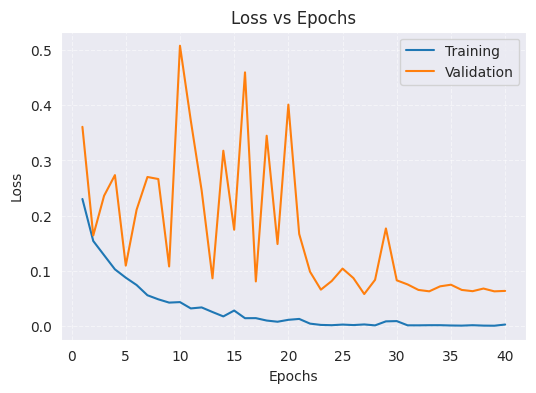

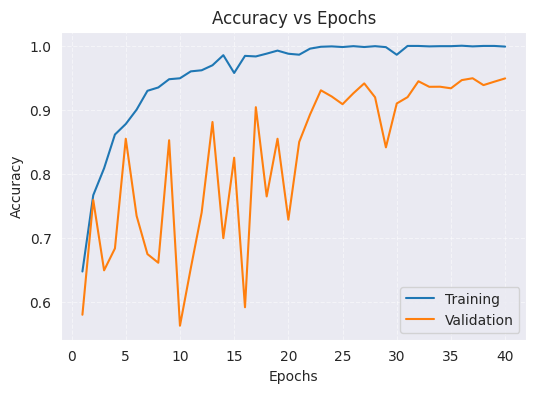

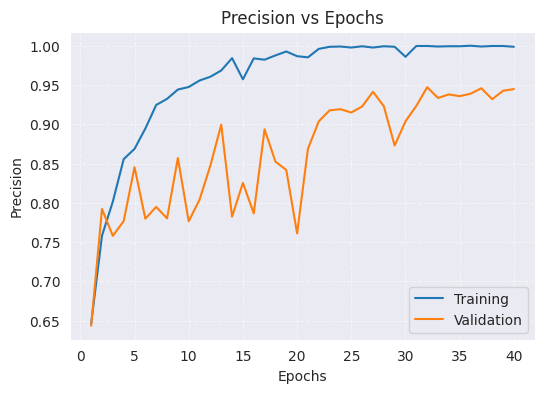

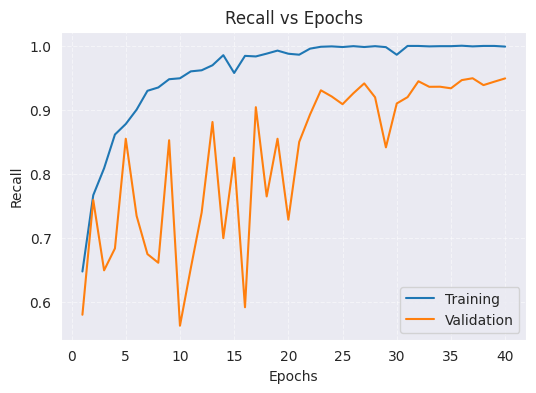

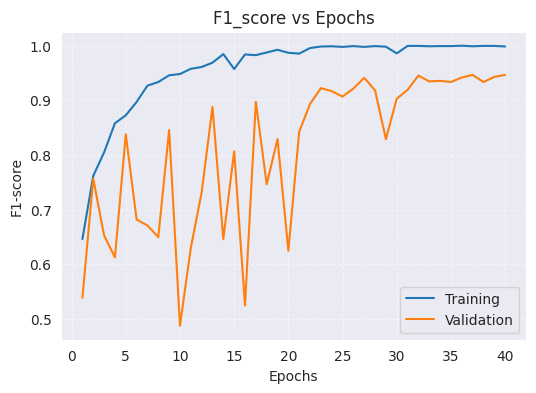

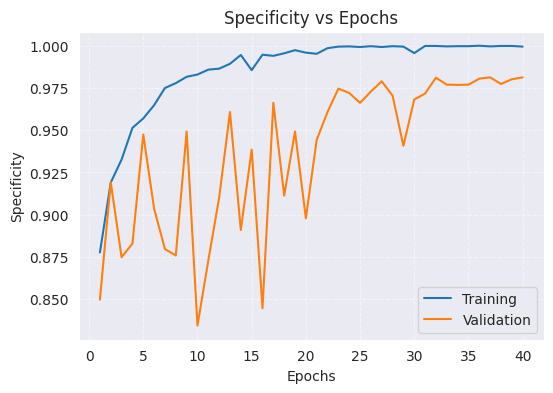

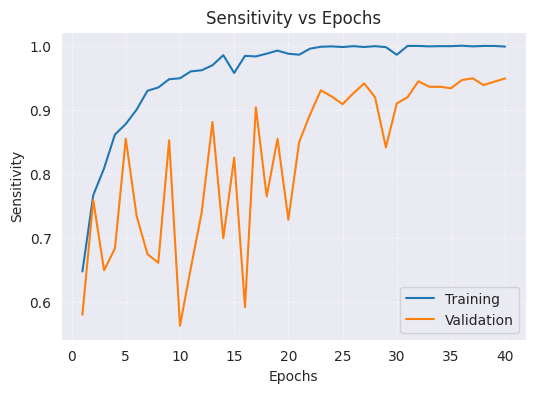

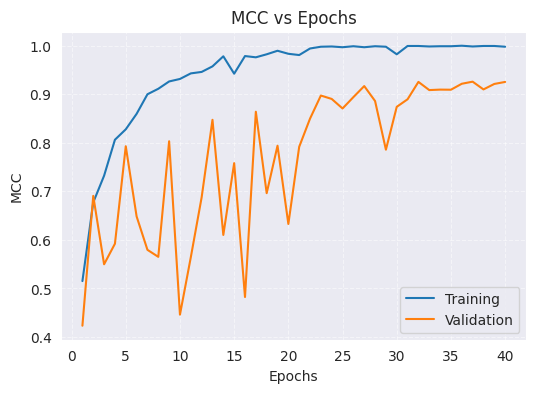

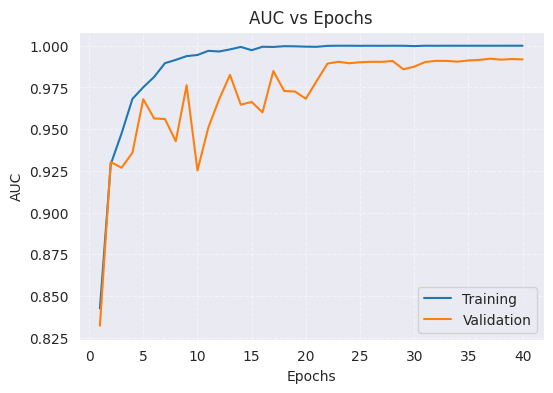

In [35]:
def plot_metric(train, val, title, ylabel):
    epochs = range(1, len(train) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train, label="Training")
    plt.plot(epochs, val, label="Validation")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


plot_metric(history["loss"], history["val_loss"], "Loss vs Epochs", "Loss")
plot_metric(history["accuracy"], history["val_accuracy"], "Accuracy vs Epochs", "Accuracy")
plot_metric(history["precision"], history["val_precision"], "Precision vs Epochs", "Precision")
plot_metric(history["recall"], history["val_recall"], "Recall vs Epochs", "Recall")
plot_metric(history["f1"], history["val_f1"], "F1_score vs Epochs", "F1-score")
plot_metric(history["specificity"], history["val_specificity"], "Specificity vs Epochs", "Specificity")
plot_metric(history["sensitivity"], history["val_sensitivity"], "Sensitivity vs Epochs", "Sensitivity")
plot_metric(history["mcc"], history["val_mcc"], "MCC vs Epochs", "MCC")
plot_metric(history["auc"], history["val_auc"], "AUC vs Epochs", "AUC")



In [36]:
model.eval()
test_metrics = {k: v.clone().to(device) for k, v in train_metrics.items()}
test_loss = 0.0
all_preds, all_targets = [], []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Testing Model")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        test_loss += loss.item()

        preds = out.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

        for m in test_metrics.values():
            m.update(out, y)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

test_spec, test_sens = multiclass_specificity_sensitivity(
    all_targets, all_preds, num_classes
)

print(
    f"Metrics - loss: {test_loss/len(test_loader):.4f}, "
    f"accuracy: {test_metrics['acc'].compute().item():.4f}, "
    f"precision: {test_metrics['precision'].compute().item():.4f}, "
    f"recall: {test_metrics['recall'].compute().item():.4f}, "
    f"f1_score: {test_metrics['f1'].compute().item():.4f}, "
    f"specificity: {test_spec:.4f}, "
    f"sensitivity: {test_sens:.4f}, "
    f"mcc: {test_metrics['mcc'].compute().item():.4f}, "
    f"auc: {test_metrics['auc'].compute().item():.4f}"
)



Testing Model: 100%|██████████| 21/21 [00:01<00:00, 16.37it/s]

Metrics - loss: 0.0350, accuracy: 0.9522, precision: 0.9521, recall: 0.9522, f1_score: 0.9521, specificity: 0.9833, sensitivity: 0.9522, mcc: 0.9337, auc: 0.9972


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]


# -------- CLASSIFICATION REPORT --------
print("\nClassification Report (Test Set):\n")

report = classification_report(
    all_targets,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)




Classification Report (Test Set):

              precision    recall  f1-score   support

      Glioma     0.9474    0.9677    0.9574        93
  Meningioma     0.9457    0.9255    0.9355        94
    No Tumor     0.9556    0.9556    0.9556        90
   Pituitary     0.9600    0.9600    0.9600        50

    accuracy                         0.9511       327
   macro avg     0.9521    0.9522    0.9521       327
weighted avg     0.9511    0.9511    0.9510       327



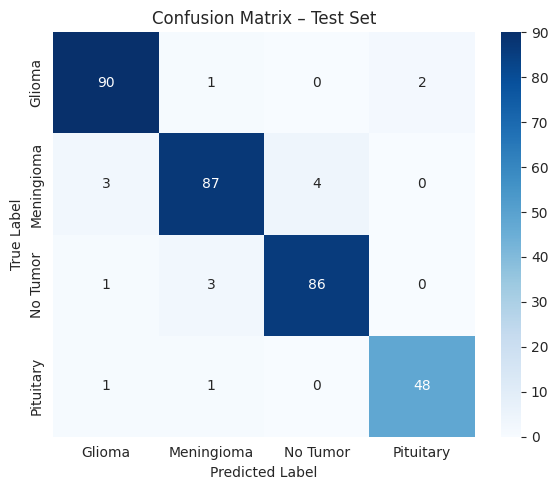

In [38]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

